In [38]:
import pandas as pd , openpyxl, matplotlib.pyplot as plt,  seaborn as sns

In [39]:
path = r"H:\PYTHON\AnaliseDeDados\CD2022_Populacao_2010_Compatibilizada_20231222 (1).xlsx"

# linha 0 vazia, linha 1 título, linha 2 cabeçalho (header=2)
df = pd.read_excel(path, header=2)





In [40]:
df = df.iloc[2:5573,1:].copy()

In [41]:
df

,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,População Município 2010\n(Sinopse),População 2010 (Alterações de Limites até 2022)1,População Censo 2022
2,RO,11.0,31.0,Cabixi,6313.0,6313.0,5351.0
3,RO,11.0,49.0,Cacoal,78574.0,78574.0,86887.0
4,RO,11.0,56.0,Cerejeiras,17029.0,17029.0,15890.0
5,RO,11.0,64.0,Colorado do Oeste,18591.0,18591.0,15663.0
6,RO,11.0,72.0,Corumbiara,8783.0,8783.0,7519.0
...,...,...,...,...,...,...,...
5568,GO,52.0,22302.0,Vila Propício,5145.0,5145.0,5815.0
5569,DF,53.0,108.0,Brasília,2570160.0,2572159.0,2817381.0
5570,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5571,Nota: Para o cálculo das taxas de crescimento ...,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
# Agrupa a população por UF em 2010 e 2022
pop_estado = (
    df.groupby("COD. UF")[["População Município 2010\n(Sinopse)", "População Censo 2022"]]
    .sum()
    .reset_index()
)

# Calcula o crescimento absoluto e ordena do maior para o menor
pop_estado["crescimento"] = pop_estado["População Censo 2022"] - pop_estado["População Município 2010\n(Sinopse)"]
pop_estado = pop_estado.sort_values(by="crescimento", ascending=False)
pop_estado.head()

,COD. UF,População Município 2010\n(Sinopse),População Censo 2022,crescimento
19,35.0,41262199.0,44411238.0,3149039.0
21,42.0,6248436.0,7610361.0,1361925.0
25,52.0,6003788.0,7056495.0,1052707.0
20,41.0,10444526.0,11444380.0,999854.0
16,31.0,19597330.0,20539989.0,942659.0


In [43]:
pop_estado.to_csv("populacao_estado.csv", sep=";", index=False)

In [44]:
# Copia a tabela original e calcula o crescimento por município
pop_municipio = df.copy()
pop_municipio["crescimento"] = pop_municipio["População Censo 2022"] - pop_municipio["População Município 2010\n(Sinopse)"]

# Ordena os municípios pelo maior crescimento
pop_municipio = pop_municipio.sort_values(by="crescimento", ascending=False)
pop_municipio.head()

,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,População Município 2010\n(Sinopse),População 2010 (Alterações de Limites até 2022)1,População Censo 2022,crescimento
111,AM,13.0,2603.0,Manaus,1802014.0,1802014.0,2063689.0,261675.0
5569,DF,53.0,108.0,Brasília,2570160.0,2572159.0,2817381.0,247221.0
3829,SP,35.0,50308.0,São Paulo,11253503.0,11253503.0,11451999.0,198496.0
3848,SP,35.0,52205.0,Sorocaba,586625.0,586816.0,723682.0,137057.0
5417,GO,52.0,8707.0,Goiânia,1302001.0,1301912.0,1437366.0,135365.0


In [45]:
pop_municipio.to_csv("populacao_municipio.csv", sep=";", index=False)

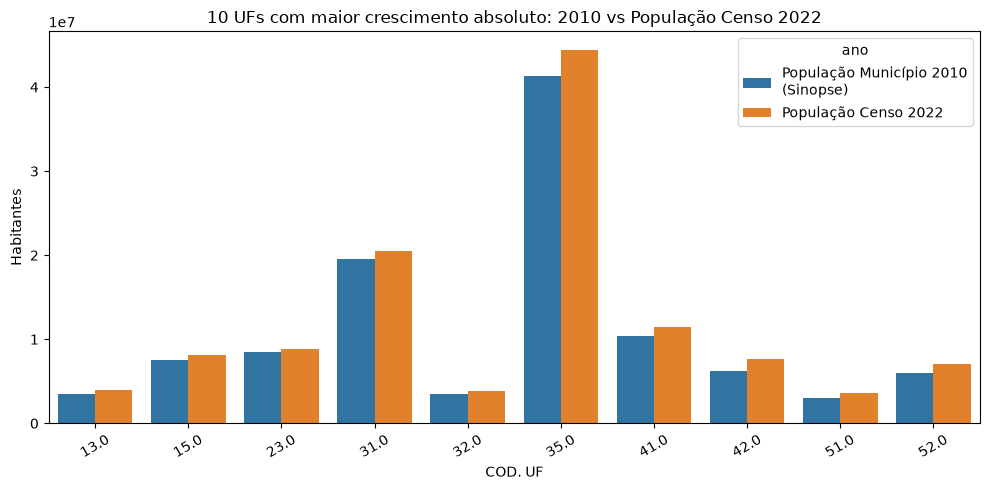

In [46]:
# Transforma os dados das 10 maiores UFs em formato longo para visualização
top = pop_estado.head(10).melt(
    id_vars="COD. UF",
    value_vars=["População Município 2010\n(Sinopse)", "População Censo 2022"],
    var_name="ano",
    value_name="populacao",
)

# Gera o gráfico de comparação 2010 vs 2022
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top, x="COD. UF", y="populacao", hue="ano", ax=ax)
ax.set_title("10 UFs com maior crescimento absoluto: 2010 vs População Censo 2022")
ax.set_ylabel("Habitantes")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()